### 🧠 What is Self-Reflection in RAG?
Self-reflection = LLM evaluates its own output:
“Is this clear, complete, and accurate?”

#### Self-Reflection in RAG using LangGraph, we’ll design a workflow where the agent:

1. Generates an initial answer using retrieved context
2. Reflects on that answer with a dedicated self-critic LLM step
3. If unsatisfied, it can revise the query, retrieve again, or regenerate the answer

In [14]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS 
from langchain_openai import OpenAIEmbeddings
from typing import TypedDict, List
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, END
from IPython.display import Markdown, display

In [2]:
load_dotenv()

True

In [3]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [4]:
llm  = init_chat_model("openai:gpt-4o", temperature = 0.3)

In [5]:
# -------------------------------
# 1. Prepare Vectorstore
# -------------------------------
# Load the document
docs = TextLoader('internal_docs.txt').load()

# split into chunks
textsplitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 200
)

chunks = textsplitter.split_documents(docs)

# store the chunks into vector store
vectorstore  = FAISS.from_documents(chunks, embedding=OpenAIEmbeddings())

# create the retriever
retriever = vectorstore.as_retriever(search_type = "similarity", search_kwargs = {"k":  3})

In [6]:
# -------------------------
# 2. State Definition
# -------------------------
class RAGReflectionState(TypedDict):

    question: str
    retrieved_docs: List[Document]
    answer: str
    reflection: str
    revised: bool
    attempts: int
    max_attempt: int

In [8]:
# -------------------------
# 3. Nodes
# -------------------------
# a. Retrieve
def retrieve_docs(state: RAGReflectionState) -> dict:
    question = state['question']
    retrieved_docs = retriever.invoke(question)
    return {"retrieved_docs": retrieved_docs}

# b. Generate Answer
def generate_answer(state: RAGReflectionState) -> dict:
    question = state['question']
    retrieved_docs = state['retrieved_docs']
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])

    prompt = PromptTemplate(
        template="""
        Use the following context to answer the question:

        Context:
        {context}

        Question:
        {question}
        """,
        input_variables=['context', 'question']
    )

    chain = prompt|llm|StrOutputParser()

    answer = chain.invoke({
        "context": context,
        "question": question
    })
    attempts = state['attempts'] + 1

    return {"answer": answer, "attempts": attempts}


# c. Self-Reflect
def reflect_on_answer(state: RAGReflectionState) -> dict:

    prompt = PromptTemplate(
        template="""
        Reflect on the following answer to see if it fully addresses the question. 
        State YES if it is complete and correct, or NO with an explanation.

        Question: {question}

        Answer: {answer}

        Respond like:
        Reflection: YES or NO
        Explanation: ...
        """,
        input_variables=['question', 'answer']
    )

    chain = prompt|llm|StrOutputParser()

    result = chain.invoke({
        "question": state['question'],
        "answer": state['answer']
    })

    is_ok = "reflection: yes" in result.lower()
    
    return {'reflection': result, 'revised': not is_ok}



In [9]:
def self_evaluation(state: RAGReflectionState):

    if not state['revised'] or state['attempts'] >= state['max_attempt']:
        return 'done'
    else:
        return 'needs_improvement'

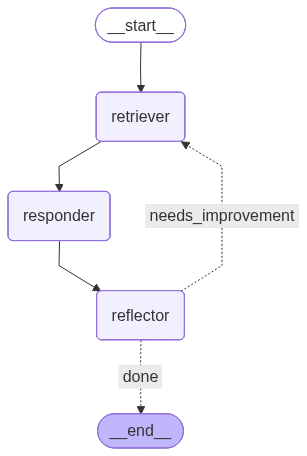

In [10]:
# -------------------------
# 4. LangGraph DAG
# -------------------------
builder = StateGraph(RAGReflectionState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)

builder.set_entry_point("retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")
builder.add_conditional_edges("reflector", self_evaluation, {"done": END, "needs_improvement": "retriever"})

graph = builder.compile()
graph

In [11]:
# invoke
question = "What are the transformer variants in production deployments?"
initial_state = {
    "question": question,
    "retrieved_docs": [],
    "answer": "",
    "reflection": "",
    "revised": False,
    "attempts": 0,
    "max_attempt": 2
}
final_state = graph.invoke(initial_state)

In [15]:
display(Markdown(final_state['answer']))

The transformer variants used in production deployments are:

1. EfficientFormer
2. LLaMA2
3. TinyBERT